Generating Ground Truth with google/gemini-3.1-pro-preview...
Ground truth generated for MBH_Tertiary_Amine.
Ground truth generated for Pd_Desulfonylative_Fluorination.
Ground truth generated for Ni_Photoredox_Cross_Electrophile.


Evaluating Models:  17%|█▋        | 1/6 [14:38<1:13:12, 878.40s/it]

Error calling google/gemini-3.1-pro-preview: 500 Server Error: Internal Server Error for url: https://openrouter.ai/api/v1/chat/completions. Retrying...


Evaluating Models:  50%|█████     | 3/6 [2:48:19<2:46:42, 3334.05s/it]

Evaluation parsing failed: 'NoneType' object has no attribute 'find'


Evaluating Models: 100%|██████████| 6/6 [3:43:21<00:00, 2233.54s/it]  


Experiment completed. Data saved to CSV.
Professional plot saved as chemistry_evaluation_professional.png.


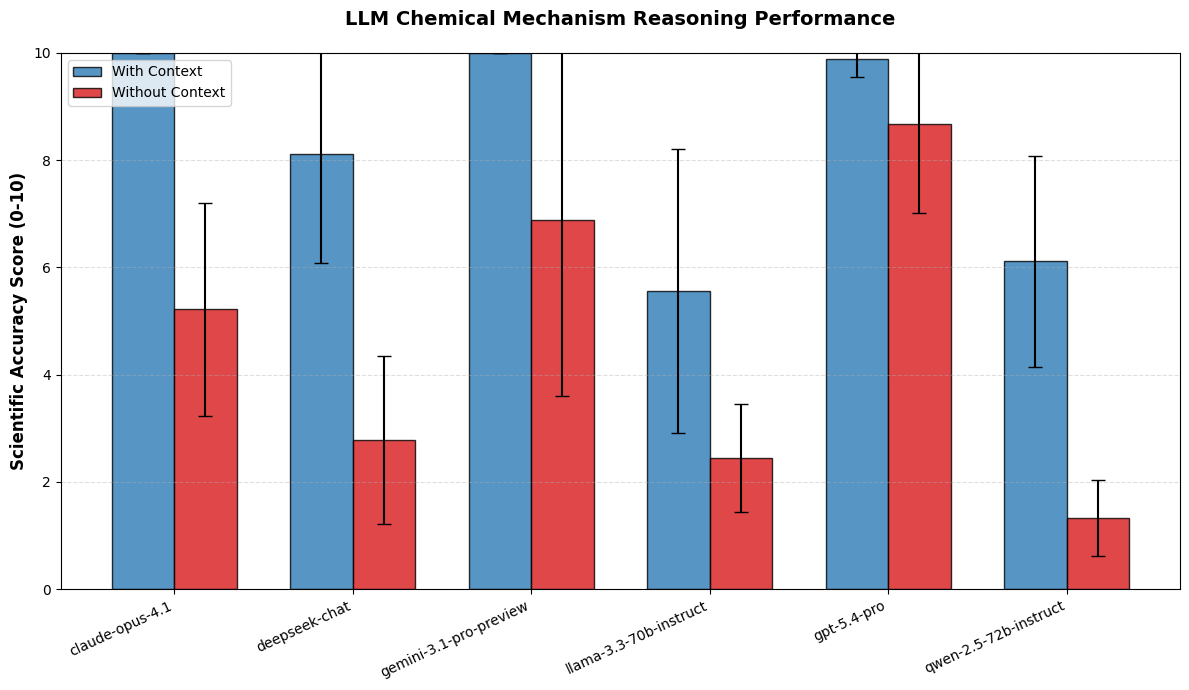

In [15]:
import requests
import json
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from tqdm import tqdm
import time
import fitz  # PyMuPDF

# ==========================================
# CONFIGURATION
# ==========================================
OPENROUTER_API_KEY = "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"

FRONTIER_MODELS = [
    "anthropic/claude-opus-4.1",
    "openai/gpt-5.4-pro",
    "google/gemini-3.1-pro-preview"
]

SMALL_MODELS = [
    "meta-llama/llama-3.3-70b-instruct",
    "deepseek/deepseek-chat",
    "qwen/qwen-2.5-72b-instruct"
]

ALL_MODELS = FRONTIER_MODELS + SMALL_MODELS
JUDGE_MODEL = "google/gemini-3.1-pro-preview"
ITERATIONS = 3  # Set to 3 for error bars

# ==========================================
# PDF EXTRACTION
# ==========================================
def extract_text_from_pdf(pdf_path):
    try:
        doc = fitz.open(pdf_path)
        return "".join([page.get_text() for page in doc])
    except Exception as e:
        print(f"Error reading {pdf_path}: {e}")
        return "Context extraction failed."

# ==========================================
# REACTION DATA
# ==========================================
REACTIONS = {
    "MBH_Tertiary_Amine": {
        "name": "Morita-Baylis-Hillman (MBH) catalyzed with a tertiary amine",
        "context": extract_text_from_pdf("recent-advances-in-catalytic-systems-for-the-mechanistically-complex-morita-baylis-hillman-reaction.pdf"),
        "ground_truth": ""
    },
    "Pd_Desulfonylative_Fluorination": {
        "name": "Pd-catalyzed desulfonylative fluorination of electron-deficient (hetero)aryl sulfonyl fluorides",
        "context": extract_text_from_pdf("Pd-catalyzed desulfonylative fluorination of electron-deficient (hetero)aryl sulfonyl fluorides.pdf"),
        "ground_truth": ""
    },
    "Ni_Photoredox_Cross_Electrophile": {
        "name": "Ni/Photoredox-Catalyzed Enantioselective Cross-Electrophile Coupling of Styrene Oxides with Aryl Iodides",
        "context": extract_text_from_pdf("ni-photoredox-catalyzed-enantioselective-cross-electrophile-coupling-of-styrene-oxides-with-aryl-iodides.pdf"),
        "ground_truth": ""
    }
}

PROMPT_TEMPLATE = """
Consider the following chemical reaction: {reaction_name}.
{context_block}
Based on chemical principles (and the provided context if any), answer:
1. What is the mechanism of this reaction? Describe the elementary steps.
2. What properties of catalysts will be favorable according to this mechanism?
"""

# ==========================================
# API HELPER
# ==========================================
def call_openrouter(model, prompt, temperature=0.7, max_retries=3):
    headers = {
        "Authorization": f"Bearer {OPENROUTER_API_KEY}",
        "Content-Type": "application/json"
    }
    data = {
        "model": model,
        "messages": [{"role": "user", "content": prompt}],
        "temperature": temperature
    }
    
    for attempt in range(max_retries):
        try:
            response = requests.post("https://openrouter.ai/api/v1/chat/completions", headers=headers, json=data)
            response.raise_for_status()
            return response.json()['choices'][0]['message']['content']
        except Exception as e:
            print(f"Error calling {model}: {e}. Retrying...")
            time.sleep(2)
    return "API_ERROR"

# ==========================================
# GROUND TRUTH & EVALUATION
# ==========================================
def generate_ground_truth():
    print(f"Generating Ground Truth with {JUDGE_MODEL}...")
    for key, rxn in REACTIONS.items():
        if rxn["context"] == "Context extraction failed.":
            print(f"Warning: PDF for {key} not found. Ensure the PDF is in the same directory.")
            
        prompt = PROMPT_TEMPLATE.format(
            reaction_name=rxn["name"],
            context_block=f"Context Document:\n{rxn['context'][:80000]}\n"
        )
        # Using temp=0.0 for deterministic, highly analytical ground truth
        truth = call_openrouter(JUDGE_MODEL, prompt, temperature=0.0)
        REACTIONS[key]["ground_truth"] = truth
        print(f"Ground truth generated for {key}.")

def evaluate_response(reaction_key, tested_model, response_text, has_context):
    ground_truth = REACTIONS[reaction_key]["ground_truth"]
    
    # Notice we intentionally omit `tested_model` from the prompt to avoid bias
    eval_prompt = f"""
    You are an expert computational chemist. Rate the response on a scale of 0 to 10.
    
    Reaction: {REACTIONS[reaction_key]["name"]}
    Model Provided Context: {has_context}
    
    RUBRIC:
    0-2: Hallucinated or fundamentally wrong chemistry.
    3-4: Correct reaction name, but incorrect or vague mechanism steps.
    5-6: Mostly correct mechanism, but misses key intermediates or stereochemical nuances.
    7-8: High accuracy, matches the provided paper context well.
    9-10: Exceptional detail, correctly identifies catalyst electronics/sterics and all transition states.
    
    GROUND TRUTH: 
    {ground_truth}
    
    MODEL RESPONSE: 
    {response_text}
    
    Return ONLY valid JSON format:
    {{
        "score": <int 0-10>,
        "justification": "<string explaining the rating>"
    }}
    """
    
    eval_result = call_openrouter(JUDGE_MODEL, eval_prompt, temperature=0.0)
    
    try:
        clean_json = eval_result[eval_result.find("{"):eval_result.rfind("}")+1]
        result_dict = json.loads(clean_json)
        return result_dict.get('score', 0), result_dict.get('justification', "Failed parsing")
    except Exception as e:
        print(f"Evaluation parsing failed: {e}")
        return 0, "Failed to parse evaluation JSON."

# ==========================================
# MAIN EXECUTION LOOP
# ==========================================
def run_experiment():
    generate_ground_truth()
    results = []
    
    for model in tqdm(ALL_MODELS, desc="Evaluating Models"):
        for rxn_key, rxn_data in REACTIONS.items():
            for use_context in [True, False]:
                truncated_context = rxn_data['context'][:80000] if len(rxn_data['context']) > 80000 else rxn_data['context']
                context_str = f"Context Document:\n{truncated_context}\n" if use_context else "No context provided."
                
                prompt = PROMPT_TEMPLATE.format(
                    reaction_name=rxn_data["name"],
                    context_block=context_str
                )
                
                for i in range(ITERATIONS):
                    response = call_openrouter(model, prompt)
                    if response == "API_ERROR":
                        score, justification = 0, "API Error"
                    else:
                        score, justification = evaluate_response(rxn_key, model, response, use_context)
                        
                    results.append({
                        "Model": model,
                        "Type": "Frontier" if model in FRONTIER_MODELS else "Non-Proprietary",
                        "Reaction": rxn_key,
                        "Context": "With Context" if use_context else "Without Context",
                        "Iteration": i+1,
                        "Score": score,
                        "Justification": justification,
                        "Raw_Response": response
                    })
    
    df = pd.DataFrame(results)
    df.to_csv("chemistry_llm_evaluation_results.csv", index=False)
    print("Experiment completed. Data saved to CSV.")
    return df

# ==========================================
# PLOTTING (PROFESSIONAL)
# ==========================================
def plot_results(csv_path="chemistry_llm_evaluation_results.csv"):
    try:
        df = pd.read_csv(csv_path)
    except FileNotFoundError:
        print(f"Error: {csv_path} not found. Run the experiment first.")
        return
        
    # Calculate Mean and StdDev for Error Bars (filling NaNs with 0 to prevent plotting errors)
    stats = df.groupby(['Model', 'Context'])['Score'].agg(['mean', 'std']).fillna(0).unstack()
    
    try:
        plt.style.use('seaborn-v0_8-muted')
    except:
        plt.style.use('ggplot') # Fallback if seaborn style isn't available
        
    fig, ax = plt.subplots(figsize=(12, 7))
    
    models = stats.index
    x = np.arange(len(models))
    width = 0.35
    
    # Plotting With Context
    ax.bar(x - width/2, stats['mean']['With Context'], width, 
           yerr=stats['std']['With Context'], capsize=5, 
           label='With Context', color='#2c7bb6', edgecolor='black', alpha=0.8)
    
    # Plotting Without Context
    ax.bar(x + width/2, stats['mean']['Without Context'], width, 
           yerr=stats['std']['Without Context'], capsize=5, 
           label='Without Context', color='#d7191c', edgecolor='black', alpha=0.8)
    
    # Styling
    ax.set_ylabel('Scientific Accuracy Score (0-10)', fontsize=12, fontweight='bold')
    ax.set_title('LLM Chemical Mechanism Reasoning Performance', fontsize=14, pad=20, fontweight='bold')
    ax.set_xticks(x)
    # Shorten model names for a cleaner X-axis (e.g., "openai/gpt-5.4-pro" -> "gpt-5.4-pro")
    ax.set_xticklabels([str(m).split('/')[-1] for m in models], rotation=25, ha='right')
    ax.set_ylim(0, 10)
    ax.legend(frameon=True, loc='upper left')
    ax.grid(axis='y', linestyle='--', alpha=0.4)
    
    plt.tight_layout()
    plt.savefig("chemistry_evaluation_professional.png", dpi=300)
    print("Professional plot saved as chemistry_evaluation_professional.png.")

# ==========================================
# EXECUTION
# ==========================================
if __name__ == "__main__":
    # 1. Run the experiment and generate the CSV
    df_results = run_experiment() 
    
    # 2. Plot the results using the generated CSV
    plot_results("chemistry_llm_evaluation_results.csv")

In [ ]:
import requests
import json
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns
from tqdm import tqdm
import time
import fitz  # PyMuPDF
import base64
from pathlib import Path

# ==========================================
# 1. CONFIGURATION & MODELS
# ==========================================
OPENROUTER_API_KEY = "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"

# Models are grouped for the plot, but will receive IDENTICAL text input
FRONTIER_MODELS = [
    "anthropic/claude-opus-4.1",
    "openai/gpt-5.4-pro",
    "google/gemini-3.1-pro-preview"
]

SMALL_MODELS = [
    "meta-llama/llama-3.3-70b-instruct",
    "deepseek/deepseek-chat",
    "qwen/qwen-2.5-72b-instruct"
]

ALL_MODELS = FRONTIER_MODELS + SMALL_MODELS
JUDGE_MODEL = "google/gemini-3.1-pro-preview"
ITERATIONS = 5 

# ==========================================
# 2. THE PROMPTS
# ==========================================
PROMPT_TEMPLATE = """
Consider the following chemical reaction: {reaction_name}.
{context_block}

Based on chemical principles (and the provided context if any), answer:
1. What is the mechanism of this reaction? Describe the elementary steps.
2. What properties of catalysts will be favorable according to this mechanism?
"""

EVAL_PROMPT_TEMPLATE = """
You are an expert computational chemist. Rate the response on a scale of 0 to 10.

Reaction: {reaction_name}
Context Provided to Model: {has_context}

RUBRIC:
0-2: Hallucinated or fundamentally wrong chemistry.
3-4: Correct reaction name, but incorrect or vague mechanism steps.
5-6: Mostly correct mechanism, but misses key intermediates or stereochemical nuances.
7-8: High accuracy, matches the provided paper context well.
9-10: Exceptional detail, correctly identifies catalyst electronics/sterics and all transition states.

GROUND TRUTH (Gold Standard): 
{ground_truth}

MODEL RESPONSE: 
{response_text}

Return ONLY valid JSON:
{{
    "score": <int>,
    "justification": "<string>"
}}
"""

# ==========================================
# 3. FAIR TEXT EXTRACTION (Borrowed form https://github.com/uni-parser/RxnBench/tree/main)
# ==========================================
def extract_pdf_text_clean(pdf_path: Path) -> str:
    """Extracts and strips whitespace for high-quality text context."""
    try:
        doc = fitz.open(str(pdf_path))
        text = [page.get_text() for page in doc]
        # RxnBench approach: clean up the noise to save tokens and improve clarity
        return "\n".join(t.strip() for t in text if t.strip())
    except Exception as e:
        print(f"Error extracting text from {pdf_path}: {e}")
        return ""

# ==========================================
# 4. DATA PREPARATION
# ==========================================
REACTIONS = {
    "MBH_Tertiary_Amine": {
        "name": "Morita-Baylis-Hillman (MBH) catalyzed with a tertiary amine",
        "file": "recent-advances-in-catalytic-systems-for-the-mechanistically-complex-morita-baylis-hillman-reaction.pdf"
    },
    "Pd_Desulfonylative_Fluorination": {
        "name": "Pd-catalyzed desulfonylative fluorination of electron-deficient (hetero)aryl sulfonyl fluorides",
        "file": "Pd-catalyzed desulfonylative fluorination of electron-deficient (hetero)aryl sulfonyl fluorides.pdf"
    },
    "Ni_Photoredox_Cross_Electrophile": {
        "name": "Ni/Photoredox-Catalyzed Enantioselective Cross-Electrophile Coupling of Styrene Oxides with Aryl Iodides",
        "file": "ni-photoredox-catalyzed-enantioselective-cross-electrophile-coupling-of-styrene-oxides-with-aryl-iodides.pdf"
    }
}

print("Extracting high-quality text context for all models...")
for key in REACTIONS:
    p = Path(REACTIONS[key]["file"])
    REACTIONS[key]["text"] = extract_pdf_text_clean(p)
    REACTIONS[key]["ground_truth"] = ""

# ==========================================
# 5. API CALL & EVALUATION
# ==========================================
def call_openrouter(model, text_prompt, temperature=0.7):
    headers = {"Authorization": f"Bearer {OPENROUTER_API_KEY}", "Content-Type": "application/json"}
    data = {
        "model": model,
        "messages": [{"role": "user", "content": text_prompt}],
        "temperature": temperature
    }
    for _ in range(3):
        try:
            r = requests.post("https://openrouter.ai/api/v1/chat/completions", headers=headers, json=data)
            return r.json()['choices'][0]['message']['content']
        except: time.sleep(2)
    return "API_ERROR"

def evaluate_response(rxn_key, response_text, has_context):
    eval_prompt = EVAL_PROMPT_TEMPLATE.format(
        reaction_name=REACTIONS[rxn_key]["name"],
        has_context="Yes" if has_context else "No",
        ground_truth=REACTIONS[rxn_key]["ground_truth"],
        response_text=response_text
    )
    res = call_openrouter(JUDGE_MODEL, eval_prompt, temperature=0)
    try:
        clean_json = res[res.find("{"):res.rfind("}")+1]
        data = json.loads(clean_json)
        return data.get('score', 0), data.get('justification', "")
    except: return 0, "Evaluation failed"

# ==========================================
# 6. EXPERIMENT RUNNER
# ==========================================
def run_fair_experiment():
    print("\nPhase 1: Generating Ground Truths...")
    for key, rxn in REACTIONS.items():
        truth_prompt = PROMPT_TEMPLATE.format(
            reaction_name=rxn["name"],
            context_block=f"Full Paper Text:\n{rxn['text'][:50000]}" # Balanced context size
        )
        rxn["ground_truth"] = call_openrouter(JUDGE_MODEL, truth_prompt, temperature=0)

    results = []
    print("\nPhase 2: Benchmarking all models on text-only context...")
    for model in tqdm(ALL_MODELS, desc="Models"):
        for rxn_key, rxn_data in REACTIONS.items():
            for use_context in [True, False]:
                
                # EQUALIZED CONTEXT: Everyone gets the same text snippet
                if use_context:
                    ctx = f"Context from research paper:\n{rxn_data['text'][:25000]}"
                else:
                    ctx = "No specific context provided. Use general chemical knowledge."

                prompt = PROMPT_TEMPLATE.format(reaction_name=rxn_data["name"], context_block=ctx)
                
                for i in range(ITERATIONS):
                    resp = call_openrouter(model, prompt)
                    score, just = evaluate_response(rxn_key, resp, use_context)
                    results.append({
                        "Model": model.split('/')[-1],
                        "Reaction": rxn_key,
                        "Context": "With Context" if use_context else "Without Context",
                        "Score": score,
                        "Type": "Proprietary" if model in FRONTIER_MODELS else "Non-Proprietary"
                    })
    
    df = pd.DataFrame(results)
    df.to_csv("fair_chemistry_results.csv", index=False)
    return df

# ==========================================
# 7. PLOTTING
# ==========================================
def plot_fair_results(csv="fair_chemistry_results.csv"):
    df = pd.read_csv(csv)
    model_order = [m.split('/')[-1] for m in ALL_MODELS]
    
    for rxn in df['Reaction'].unique():
        plt.figure(figsize=(14, 8))
        rxn_df = df[df['Reaction'] == rxn]
        
        sns.boxplot(data=rxn_df, x='Model', y='Score', hue='Context', order=model_order,
                    palette=['#2ecc71', '#e67e22'], showfliers=False, boxprops=dict(alpha=.3))
        
        sns.stripplot(data=rxn_df, x='Model', y='Score', hue='Context', order=model_order,
                      dodge=True, jitter=True, marker='o', alpha=0.7, palette=['#27ae60', '#d35400'])
        
        plt.axvline(x=len(FRONTIER_MODELS)-0.5, color='black', lw=2, linestyle=':')
        plt.title(f"Fair Benchmark (Text-Only Context): {rxn}", fontsize=14)
        plt.ylim(-0.5, 11)
        plt.ylabel("Accuracy Score (0-10)")
        plt.xticks(rotation=15)
        
        h, l = plt.gca().get_legend_handles_labels()
        plt.legend(h[:2], l[:2], title="Condition", loc='lower left')
        
        plt.tight_layout()
        plt.savefig(f"fair_plot_{rxn}.png")

if __name__ == "__main__":
    # results = run_fair_experiment()
    plot_fair_results("fair_chemistry_results.csv")